In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr

# --- DISCHARGE (GRDC) ---

# Load the GRDC text file
df = pd.read_csv('./Data/5202080_Q_Day.Cmd.txt',delimiter=';',skiprows=36,header=0,encoding='cp1252')

# Rename columns
df.columns = ["Date", "Time", "Discharge"]
# Convert discharge to numeric (GRDC uses -999 for missing)
df["Discharge"] = pd.to_numeric(df["Discharge"], errors="coerce")
# Drop missing discharge values
df = df.dropna(subset=["Discharge"])
# Convert Date column to datetime
df["Date"] = pd.to_datetime(df["Date"], format="%Y-%m-%d")
# Set datetime index
df = df.set_index("Date")
# Drop the useless Time column
df = df.drop(columns=["Time"])
# Sort by date (just in case)
df = df.sort_index()


In [2]:
# Load evaporation data from ERA5
# Header: system:index,total_evaporation_sum 
# Example: system:index,total_evaporation_sum 19810101,-0.00420383256061009
evap_daily_df = pd.read_csv("./Data/manning_ERA5_evap_daily.csv")
evap_daily_df['Date'] = pd.to_datetime(evap_daily_df['system:index'], format='%Y%m%d')
evap_daily_df = evap_daily_df.set_index('Date')[['total_evaporation_sum']].rename(columns={'total_evaporation_sum': 'ERA5_Evaporation'})
# Take absolute value since evaporation is negative in ERA5 data
evap_daily_df['ERA5_Evaporation'] = evap_daily_df['ERA5_Evaporation'].abs()


In [3]:
# Load precip data from CHIRPS
# Header: system:index,precipitation
chirps_df = pd.read_csv("./Data/manning_chirps_precip_daily.csv")
chirps_df['Date'] = pd.to_datetime(chirps_df['system:index'], format='%Y%m%d')
chirps_df = chirps_df.set_index('Date')[['precipitation']].rename(columns={'precipitation': 'CHIRPS_Precipitation'})    
evap_daily = evap_daily_df.copy()
precip_daily = chirps_df.copy()


In [4]:
# Select data from the same time periods (1981-2025)
# Find common dates between evaporation, precipitation, and discharge

common_dates = evap_daily.index.intersection(precip_daily.index).intersection(df.index)

evap_common = evap_daily.loc[common_dates]
precip_common = precip_daily.loc[common_dates]
discharge_common = df.loc[common_dates]

# # For monthly data, resample the common daily data
# evap_monthly_common = evap_common.resample("ME").mean()
# precip_monthly_common = precip_common.resample("ME").mean()
# discharge_monthly_common = discharge_common.resample("ME").mean()

In [5]:
#daily averages
P_mean_mm_day = precip_common["CHIRPS_Precipitation"].mean()
Ep_mean_m_day = evap_common["ERA5_Evaporation"].mean()
Q_mean_m3s = discharge_common["Discharge"].mean()

# Catchment area from stationbasins.geojson
area_km2 = 8000  # km²
area_m2 = area_km2 * 1e6  # m²

#yearly averages
P_mean_mm_year = P_mean_mm_day * 365
Ep_mean_mm_year = Ep_mean_m_day * 1000 * 365
Q_mean_mm_year = ((Q_mean_m3s * 86400) / area_m2 * 1000) * 365




print(f"Average Discharge (Q): {Q_mean_mm_year:.2f} mm/year")
print(f"Average Precipitation (P): {P_mean_mm_year:.2f} mm/year")
print(f"Average Evaporation (Ep): {Ep_mean_mm_year:.2f} mm/year")

Average Discharge (Q): 118.10 mm/year
Average Precipitation (P): 1042.23 mm/year
Average Evaporation (Ep): 920.90 mm/year


In [6]:
AI = Ep_mean_mm_year / P_mean_mm_year
EI = 1 - (Q_mean_mm_year / P_mean_mm_year)

print(P_mean_mm_day)
print(Ep_mean_m_day)
print(Q_mean_m3s)

# Print
print(f"Aridity Index (AI): {AI:.2f}")
print(f"Evaporative Index (EI): {EI:.2f}")

2.8554177970714107
0.002523019595995361
29.958738695329874
Aridity Index (AI): 0.88
Evaporative Index (EI): 0.89


In [7]:
# 3. ANALYTICAL BUDYKO CURVES
phi = np.linspace(0.01, 5, 500)

EaP_schreiber = 1 - np.exp(-phi)
EaP_oldekop = phi * np.tanh(1 / phi)
EaP_budyko = np.sqrt(phi * np.tanh(1/phi) * (1 - np.exp(-phi)))
EaP_turc = 1 / np.sqrt(0.9 + (1/phi)**2)


<Figure size 800x600 with 0 Axes>

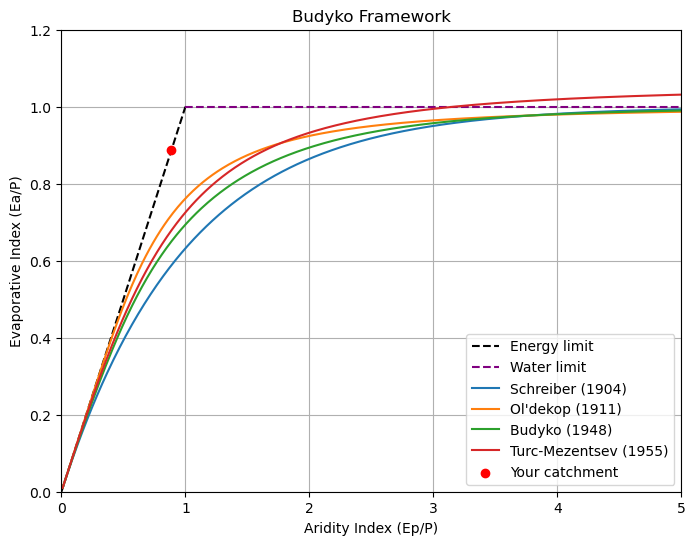

The catchment has an aridity index of a humid climate, which is normal for a coastal region. The evaporative index indicates that a significant portion of precipitation is lost to evaporation, which is also typical for humid climates. The catchment falls below the water limit, suggesting that it is not energy-limited and has sufficient water availability for evaporation.   


In [16]:
plt.figure(figsize=(8,6))
plt.figure(figsize=(8,6))
plt.xlim(0, 5)
plt.ylim(0, 1.2)

# --- Physically valid Budyko limits ---

# Energy limit: only from phi = 0 to phi = 1
phi_energy = np.linspace(0, 1, 200)
plt.plot(phi_energy, phi_energy, 'k--', label='Energy limit')

# Water limit: only from phi = 1 to phi = 5
phi_water = np.linspace(1, 5, 200)
plt.hlines(1, 1, 5, colors='purple', linestyles='--', label='Water limit')

# Analytical curves
plt.plot(phi, EaP_schreiber, label='Schreiber (1904)')
plt.plot(phi, EaP_oldekop, label='Ol\'dekop (1911)')
plt.plot(phi, EaP_budyko, label='Budyko (1948)')
plt.plot(phi, EaP_turc, label='Turc-Mezentsev (1955)')

# Your catchment point
plt.scatter(AI, EI, color='red', label='Your catchment', zorder=5)


plt.xlabel("Aridity Index (Ep/P)")
plt.ylabel("Evaporative Index (Ea/P)")
plt.title("Budyko Framework")
plt.legend()
plt.grid(True)
plt.show()

print(f'The catchment has an aridity index of a humid climate, which is normal for a coastal region. The evaporative index indicates that a significant portion of precipitation is lost to evaporation, which is also typical for humid climates. The catchment falls below the water limit, suggesting that it is not energy-limited and has sufficient water availability for evaporation.   ')

In [9]:
#PROBLEM 2 - FLOW DURATION CURVES for the catchment area of 8000 km²
#flow duration curve is plotted as exceedence probability by runoff


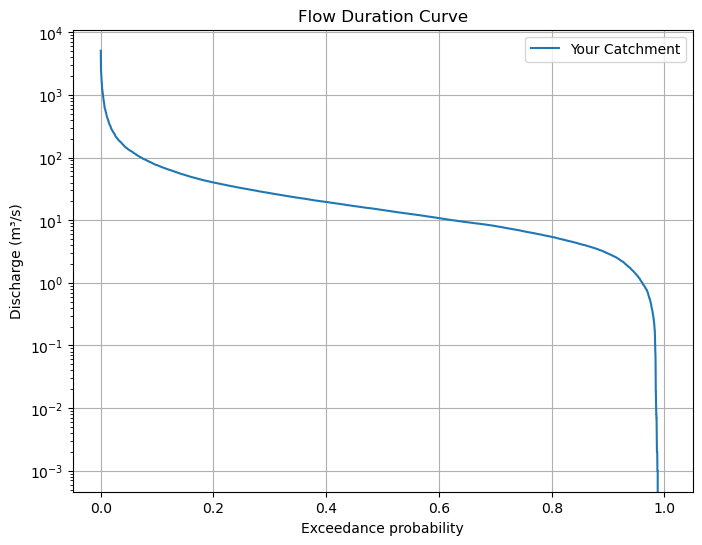

In [10]:
def flow_duration_curve(Q):
    Q_sorted = np.sort(Q)[::-1]  # descending
    N = len(Q_sorted)
    exceedance = np.arange(1, N+1) / (N+1)
    return exceedance, Q_sorted

exceedance, Q_sorted = flow_duration_curve(discharge_common["Discharge"])

plt.figure(figsize=(8,6))
plt.plot(exceedance, Q_sorted, label="Your Catchment")

plt.yscale("log")  # FDCs are almost always plotted on log scale
plt.xlabel("Exceedance probability")
plt.ylabel("Discharge (m³/s)")
plt.title("Flow Duration Curve")
plt.grid(True)
plt.legend()
plt.show()

In [11]:
#PROBLEM 3 - AUTO CORRELATION FUNCTION


In [12]:
def autocorrelation(x, max_lag=30):
    x = x - np.mean(x)
    result = []
    denom = np.sum(x**2)
    for lag in range(max_lag+1):
        num = np.sum(x[:-lag] * x[lag:]) if lag > 0 else np.sum(x * x)
        result.append(num / denom)
    return np.array(result)

lags = np.arange(0, 31)
acf = autocorrelation(discharge_common["Discharge"], max_lag=30)

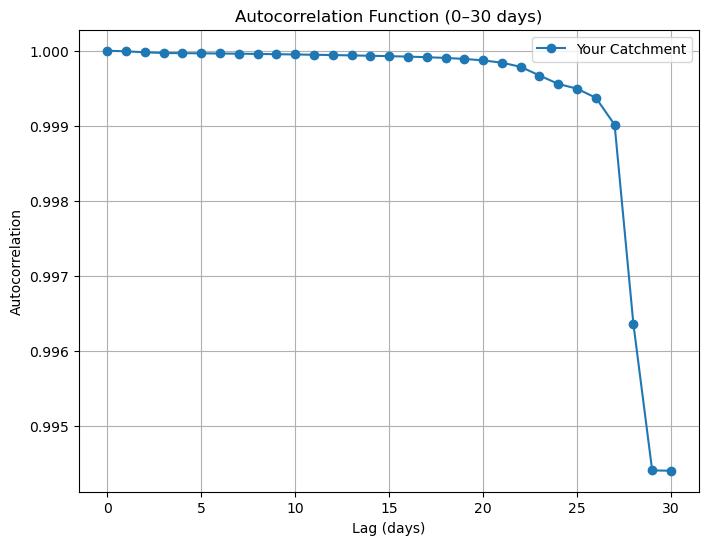

In [13]:
plt.figure(figsize=(8,6))
plt.plot(lags, acf, marker='o', label="Your Catchment")

plt.xlabel("Lag (days)")
plt.ylabel("Autocorrelation")
plt.title("Autocorrelation Function (0–30 days)")
plt.grid(True)
plt.legend()
plt.show()